# BDF Quickstart: Detect → Normalize → Visualize

This notebook shows a minimal workflow using the **bdf** package:

1. **Detect** which cycler produced a raw file (e.g., Bio-Logic `.mpt`)
2. **Normalize** the raw file into **BDF** canonical columns
3. **Visualize** with line plots (e.g., `Voltage / V` vs `Test Time / s`)

**Prerequisite:** from the repository root, run `pip install -e .` once in your environment so the `bdf` package is importable.


In [10]:
from pathlib import Path
import pandas as pd

# Core BDF API
from bdf import detect_cycler, read_raw_to_bdf
from bdf.io import load as load_bdf, save_csv
from bdf.visualize import line_plot
from bdf import read_raw_to_bdf, validate_bdf

# (Optional) nicer display
pd.set_option("display.max_columns", 50)


## Configure paths

Update `RAW_FILE` if your file lives elsewhere.  
The normalized BDF output will be written to `out/demo.bdf.csv`.


In [11]:
from pathlib import Path

RAW_FILE = Path("../data/SINTEF__NaCR32140-MP10-04__2025-08-25__CCCV_0p02C_25degC__BioLogic.mpt")
BDF_OUT  = Path("../out/demo.bdf.csv")
BDF_OUT.parent.mkdir(parents=True, exist_ok=True)

assert RAW_FILE.exists(), f"Raw file not found: {RAW_FILE}"
RAW_FILE, BDF_OUT


(WindowsPath('../data/SINTEF__NaCR32140-MP10-04__2025-08-25__CCCV_0p02C_25degC__BioLogic.mpt'),
 WindowsPath('../out/demo.bdf.csv'))

## 1) Detect cycler


In [12]:
sr = detect_cycler(RAW_FILE)
print(f"Detected plugin: {sr.id}  (confidence={sr.confidence:.2f})")
print(f"Reason: {sr.reason}")


Detected plugin: biologic-mpt  (confidence=0.90)
Reason: ext+magic


## 2) Normalize to BDF

`read_raw_to_bdf` auto-detects the parser, reads the vendor table, maps headers to the BDF canonical schema, and converts units (e.g., mA → A).


In [13]:
df_bdf = read_raw_to_bdf(RAW_FILE, validate=True)  # raises on invalid
df_bdf.head()


,Test Time / s,Voltage / V,Current / A,Ambient Temperature / degC,Step Time / s
0,0.000000,3.177719,0.0,21.297337,0.000000
1,10.000000,3.177679,0.0,21.605505,10.000000
2,20.000001,3.177719,0.0,21.471176,20.000001
3,30.000001,3.177719,0.0,21.431667,30.000001
4,40.000002,3.177798,0.0,21.368454,40.000002


### (Optional) Save normalized BDF to disk


In [14]:
save_csv(df_bdf, BDF_OUT)
print(f"Wrote: {BDF_OUT.resolve()}")


Wrote: C:\Users\simonc\Documents\Github-local\battery_data_alliance\battery-data-format\out\demo.bdf.csv


## 3) Visualize

Plot simple **Voltage vs Time** and **Current vs Time** line plots.  
You can change `xdata` / `ydata` to any BDF column names (e.g., `"Current / A"`, `"Ambient Temperature / degC"`).


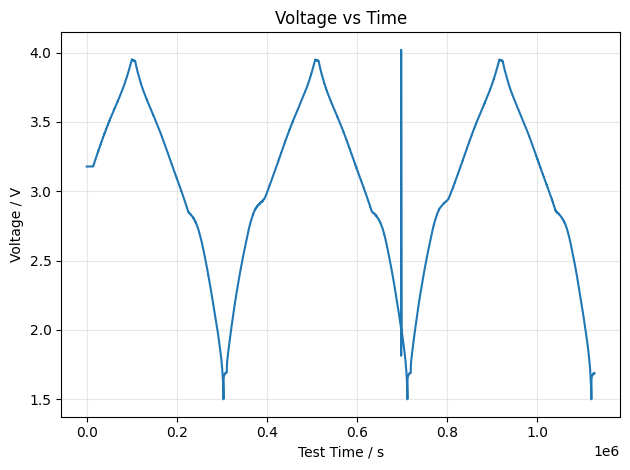

In [15]:
# Voltage vs Time
fig1 = line_plot(
    df_bdf,
    xdata="Test Time / s",
    ydata="Voltage / V",
    title="Voltage vs Time",
    save="out/voltage_vs_time.png",
)


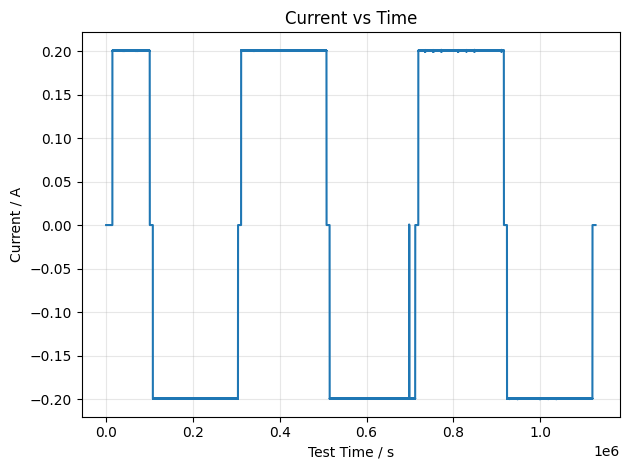

In [16]:
# Current vs Time
fig2 = line_plot(
    df_bdf,
    xdata="Test Time / s",
    ydata="Current / A",
    title="Current vs Time",
    save="out/current_vs_time.png",
)


### What BDF columns are available?


In [17]:
sorted(df_bdf.columns.tolist())


['Ambient Temperature / degC',
 'Current / A',
 'Step Time / s',
 'Test Time / s',
 'Voltage / V']

## (Alt) Load a BDF file directly and plot

If you already have a BDF CSV/Parquet, load with `bdf.io.load` and plot immediately.


True [] ['Potential outliers in Current / A: 53858 points (47.73%) flagged by robust MAD z>8.0. Examples: 0, 0, 0']
Saved plot → out/vi_vs_time.png


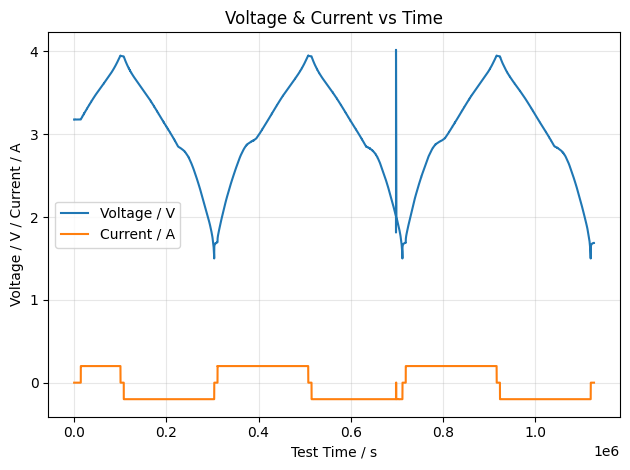

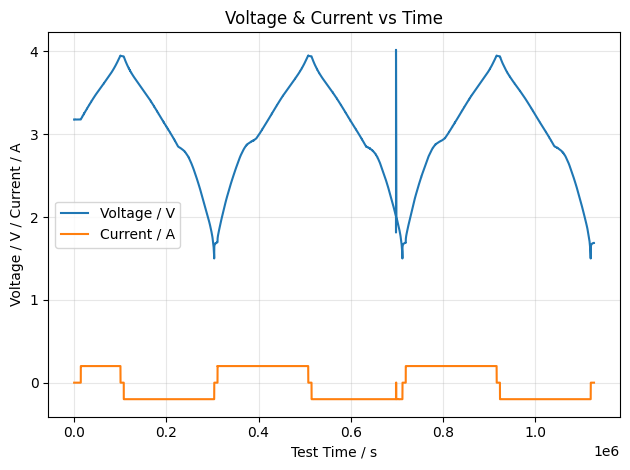

In [18]:
# validate an external file that claims to be BDF:
report = validate_bdf(BDF_OUT)
print(report.ok, report.errors, report.warnings)

df2 = load_bdf(BDF_OUT)

fig3 = line_plot(
    df2,
    xdata="Test Time / s",
    ydata=["Voltage / V", "Current / A"],
    title="Voltage & Current vs Time",
    save="out/vi_vs_time.png",
)
print("Saved plot → out/vi_vs_time.png")
fig3
